# Bank Marketing Prediction using Machine Learning (Logistic Regression)

This project predicts whether a customer will subscribe to a bank term deposit based on personal, social, and campaign-related information.

The machine learning model used is **Logistic Regression**, which is suitable for binary classification tasks such as predicting yes/no outcomes.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load Dataset

We load the bank dataset and inspect its structure.

In [2]:
df = pd.read_csv("bank.csv")   # no sep needed for this file

# If using UCI dataset:
# df = pd.read_csv("bank-additional-full.csv", sep=";")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


## Dataset Overview

We check:
- Dataset shape
- Sample rows
- Columns
- Target variable

In [3]:
print("Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

# Handle both possible target columns
target_col = "deposit" if "deposit" in df.columns else "y"

print("\nTarget Distribution:")
print(df[target_col].value_counts())

Shape: (11162, 17)

First 5 Rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  

Columns:
Index(['age', 'job', 'marital', 'education', 'default',

## Exploratory Data Analysis (EDA)

We visualize patterns in customer demographics and term deposit subscription.

### Age Distribution

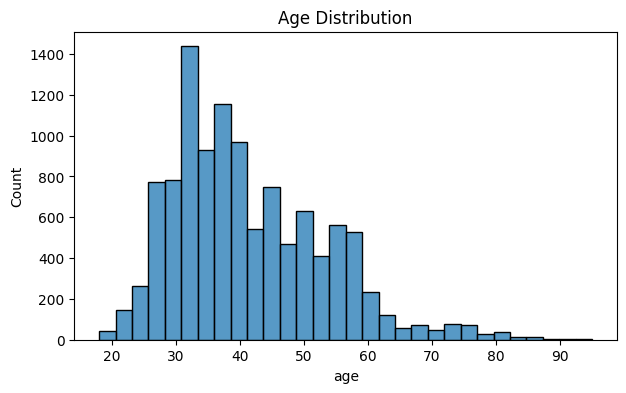

In [4]:
plt.figure(figsize=(7,4))
sns.histplot(df["age"], bins=30)

plt.title("Age Distribution")

plt.show()

### Job vs Loan Acceptance

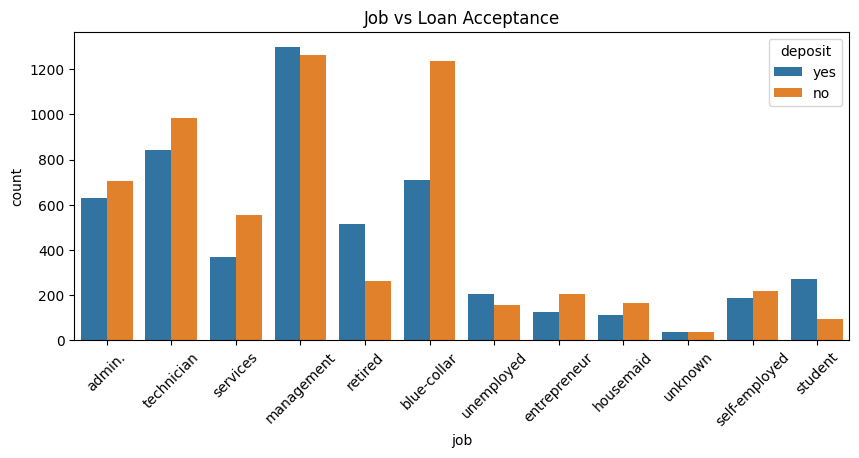

In [5]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="job", hue=target_col)

plt.xticks(rotation=45)

plt.title("Job vs Loan Acceptance")

plt.show()

### Marital Status vs Loan Acceptance

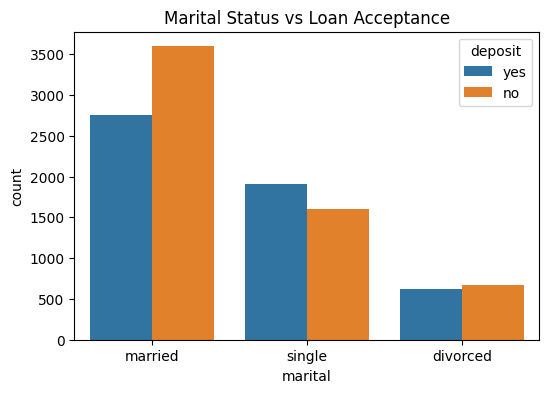

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="marital", hue=target_col)

plt.title("Marital Status vs Loan Acceptance")

plt.show()

## Data Preprocessing

We:
- Convert target values (yes/no → 1/0)
- Encode categorical variables using one-hot encoding

In [7]:
# Convert target safely
df[target_col] = df[target_col].map({"yes": 1, "no": 0})

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

print("Dataset after preprocessing:")
print(df.head())

Dataset after preprocessing:
   age  balance  day  duration  campaign  pdays  previous  deposit  \
0   59     2343    5      1042         1     -1         0        1   
1   56       45    5      1467         1     -1         0        1   
2   41     1270    5      1389         1     -1         0        1   
3   55     2476    5       579         1     -1         0        1   
4   54      184    5       673         2     -1         0        1   

   job_blue-collar  job_entrepreneur  ...  month_jul  month_jun  month_mar  \
0            False             False  ...      False      False      False   
1            False             False  ...      False      False      False   
2            False             False  ...      False      False      False   
3            False             False  ...      False      False      False   
4            False             False  ...      False      False      False   

   month_may  month_nov  month_oct  month_sep  poutcome_other  \
0       True    

## Feature Selection

We separate:
- Features (X)
- Target (y)

In [8]:
X = df.drop(target_col, axis=1)
y = df[target_col]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (11162, 42)
Target shape: (11162,)


## Train Test Split

Dataset is divided into:
- 80% Training Data
- 20% Testing Data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (8929, 42)
Testing data shape: (2233, 42)


## Logistic Regression Model Training

In [10]:
model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Model Prediction

In [11]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


## Model Evaluation

We evaluate:
- Accuracy Score
- Confusion Matrix
- Classification Report

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8119122257053292

Confusion Matrix:
[[976 190]
 [230 837]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82      1166
           1       0.81      0.78      0.80      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



## Confusion Matrix Visualization

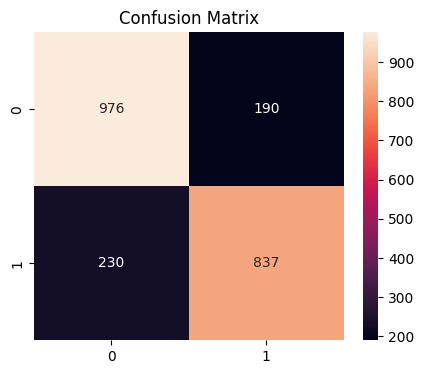

In [13]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.show()

## Business Insight

We analyze which features positively or negatively influence customer subscription.

In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Impact": model.coef_[0]
}).sort_values(by="Impact", ascending=False)

print("Top Positive Influencers:")
print(importance.head(10))

print("\nTop Negative Influencers:")
print(importance.tail(10))

Top Positive Influencers:
               Feature    Impact
40    poutcome_success  2.034420
34           month_mar  1.376819
37           month_oct  1.016103
38           month_sep  0.857377
14         job_student  0.458860
21  education_tertiary  0.451858
29           month_dec  0.433732
11         job_retired  0.377380
33           month_jun  0.329006
22   education_unknown  0.191361

Top Negative Influencers:
              Feature    Impact
12  job_self-employed -0.304281
25           loan_yes -0.468789
41   poutcome_unknown -0.645930
35          month_may -0.717635
24        housing_yes -0.727350
31          month_jan -0.883933
28          month_aug -0.887485
32          month_jul -0.944766
36          month_nov -1.127084
27    contact_unknown -1.626561


## Feature Impact Visualization

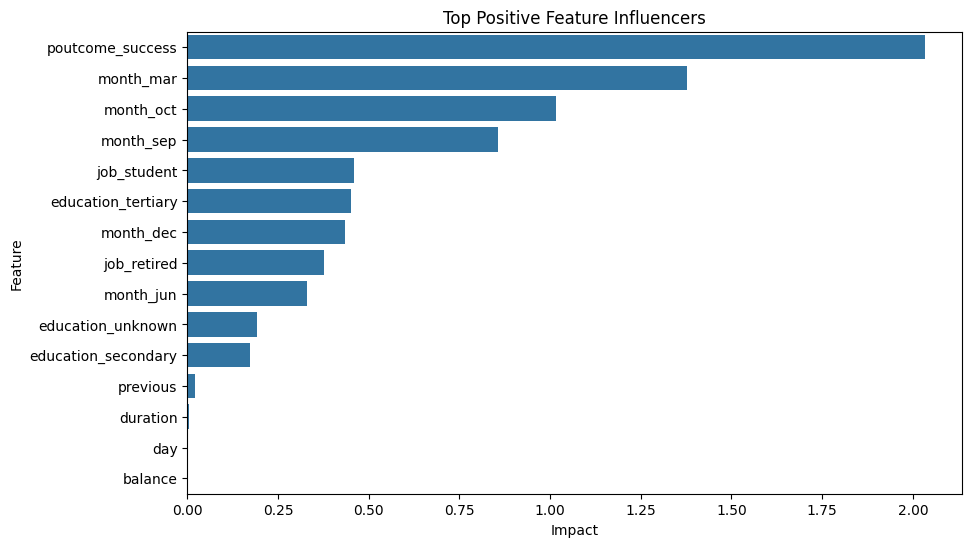

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15), x="Impact", y="Feature")

plt.title("Top Positive Feature Influencers")

plt.show()

## Conclusion

In this project:

- Bank marketing dataset was loaded and explored  
- Customer demographics were visualized  
- Data was preprocessed and encoded  
- Logistic Regression model was trained  
- Customer subscription was predicted  
- Model performance was evaluated  
- Business insights were generated from feature impacts  

This project demonstrates a full machine learning workflow for bank marketing prediction.